# 🍽️ Proyecto Final — Ciencia de Datos: Base de Datos Cafetería
### Inspección, Perfilado y Preprocesamiento
**Asignatura:** Introducción a la Ciencia de Datos  
**Programa:** Ingeniería Electrónica — ITM  
**Variable objetivo:** `Propina`


## 1. Importar Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11


## 2. Carga del Dataset

In [2]:
df = pd.read_excel("Base_de_datos_Cafeteria.xlsx")

print(f"✅ Dataset cargado correctamente")
print(f"   Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head(3)


✅ Dataset cargado correctamente
   Dimensiones: 30,132 filas × 20 columnas


,Fecha,Hora de Cobro,Mesa,Vendedor,Tipo,Producto,Categoria,Precio,Cantidad,Propina,Tipode,Tipo de pago,Pais,Departamento,Nombre,Municipio,Codigo Ciudad,Latitud,Longitud,Zona
0,2021-01-30,0.999306,17,Mauricio,Comida,Arrachera del Chef,Platos Fuertes,27000,95.85,0.0020,Nuevo,Contado,Colombia,Tolima,Villahermosa,Villahermosa,73870,5.03300,-75.1170,Nevados
1,2021-01-30,0.999306,17,Mauricio,Comida,Arrachera del Chef,Platos Fuertes,27000,95.85,0.0020,Nuevo,Contado,Colombia,Tolima,Honda,Honda,73349,5.19831,-74.7486,Norte
2,2021-08-31,0.900000,6,Valentina,Comida,Arrachera del Chef,Platos Fuertes,27000,95.85,0.0008,Nuevo,Contado,Colombia,Tolima,Piedras,Piedras,73547,4.54075,-74.8807,Ibagué


## 3. Inspección Técnica y Perfilado Estadístico Inicial
Evaluamos dimensiones, tipos de datos, valores nulos, duplicados y estadísticas descriptivas.


In [3]:
print("=" * 55)
print("  INSPECCIÓN GENERAL DEL DATASET")
print("=" * 55)
print(f"  Filas       : {df.shape[0]:,}")
print(f"  Columnas    : {df.shape[1]}")
print(f"  Duplicados  : {df.duplicated().sum()}")
print(f"  Valores nulos totales: {df.isnull().sum().sum()}")
print("=" * 55)


  INSPECCIÓN GENERAL DEL DATASET
  Filas       : 30,132
  Columnas    : 20
  Duplicados  : 1
  Valores nulos totales: 0


In [4]:
# Tipos de datos y valores nulos por columna
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
print(info.to_string())


                         Tipo  Nulos  % Nulos  Únicos
Fecha          datetime64[us]      0      0.0    1774
Hora de Cobro         float64      0      0.0      48
Mesa                    int64      0      0.0      17
Vendedor                  str      0      0.0       9
Tipo                      str      0      0.0       2
Producto                  str      0      0.0      69
Categoria                 str      0      0.0      10
Precio                  int64      0      0.0      41
Cantidad              float64      0      0.0      66
Propina               float64      0      0.0      14
Tipode                    str      0      0.0       2
Tipo de pago              str      0      0.0       2
Pais                      str      0      0.0       1
Departamento              str      0      0.0       1
Nombre                    str      0      0.0      47
Municipio                 str      0      0.0      47
Codigo Ciudad           int64      0      0.0      47
Latitud               float6

In [5]:
# Estadísticas descriptivas de variables numéricas
df.describe().round(4)


,Fecha,Hora de Cobro,Mesa,Precio,Cantidad,Propina,Codigo Ciudad,Latitud,Longitud
count,30132,30132.0000,30132.0000,30132.0000,30132.0000,30132.0000,30132.0000,30132.0000,30132.0000
mean,2019-09-18 19:46:17.060932,0.7826,9.1538,13617.6092,52.1282,0.0012,73404.8940,4.3208,-75.0332
min,2018-02-01 00:00:00,0.5400,1.0000,3600.0000,12.6000,0.0005,73001.0000,3.2000,-75.6500
25%,2018-05-21 00:00:00,0.6700,5.0000,5000.0000,20.0000,0.0008,73217.0000,3.9000,-75.1208
50%,2018-09-14 00:00:00,0.7900,9.0000,8000.0000,32.4000,0.0012,73408.0000,4.1988,-74.9670
75%,2019-01-06 00:00:00,0.9000,14.0000,16000.0000,66.3600,0.0015,73585.0000,4.8670,-74.8865
max,2025-12-31 00:00:00,1.0000,17.0000,151600.0000,553.3400,0.0020,73873.0000,5.2000,-74.5330
std,NaN,0.1361,4.8918,16157.6355,57.6179,0.0004,249.3723,0.5679,0.2607


### 3.1 Distribución de la Variable Objetivo: Propina

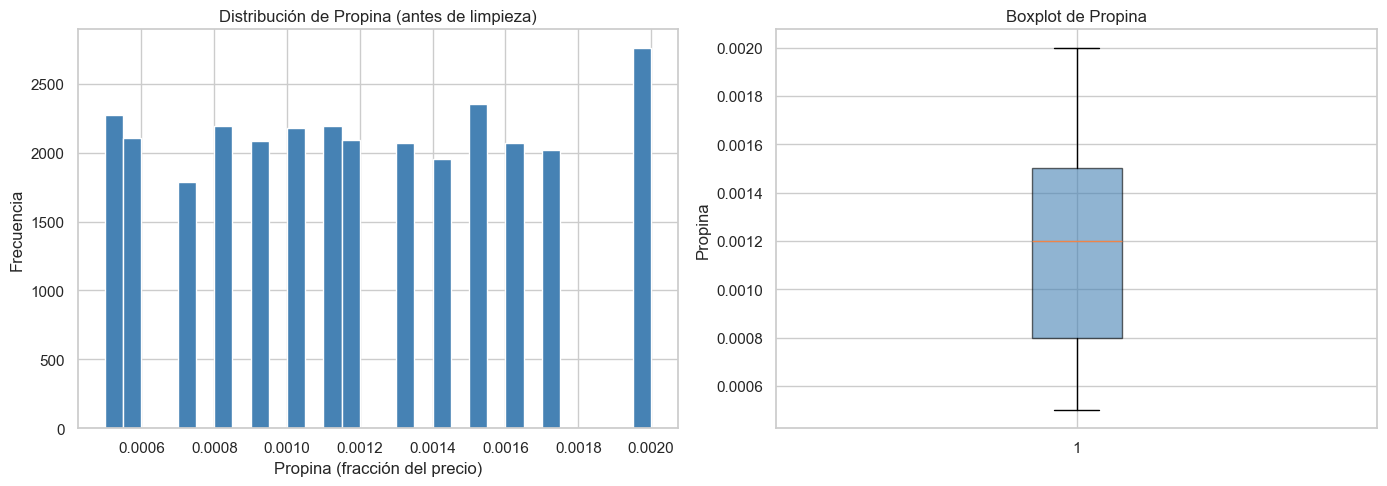

Rango Propina: [0.0005, 0.0020]
Media: 0.0012 | Mediana: 0.0012


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Propina'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Propina (antes de limpieza)')
axes[0].set_xlabel('Propina (fracción del precio)')
axes[0].set_ylabel('Frecuencia')

# Boxplot
axes[1].boxplot(df['Propina'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot de Propina')
axes[1].set_ylabel('Propina')

plt.tight_layout()
plt.savefig('propina_dist_inicial.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Rango Propina: [{df['Propina'].min():.4f}, {df['Propina'].max():.4f}]")
print(f"Media: {df['Propina'].mean():.4f} | Mediana: {df['Propina'].median():.4f}")


### 3.2 Detección de Outliers en Variable `Cantidad`

Rango IQR: [-49.54, 135.90]
Outliers detectados: 1,182 (3.92%)


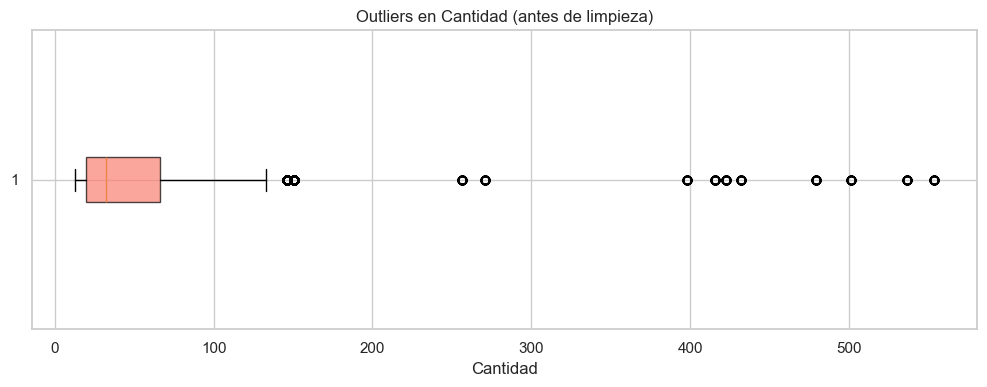

In [7]:
Q1 = df['Cantidad'].quantile(0.25)
Q3 = df['Cantidad'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Cantidad'] < lower) | (df['Cantidad'] > upper)]
print(f"Rango IQR: [{lower:.2f}, {upper:.2f}]")
print(f"Outliers detectados: {len(outliers):,} ({len(outliers)/len(df)*100:.2f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(df['Cantidad'], vert=False, patch_artist=True,
           boxprops=dict(facecolor='salmon', alpha=0.7))
ax.set_title('Outliers en Cantidad (antes de limpieza)')
ax.set_xlabel('Cantidad')
plt.tight_layout()
plt.savefig('outliers_cantidad_inicial.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Variable `Hora de Cobro` — Análisis de formato

In [8]:
# La hora está en formato decimal (fracción del día): 0.55 = 13:12, 1.0 = 24:00
print("Hora de Cobro — primeras filas (formato decimal):")
print(df['Hora de Cobro'].head(10).values)

# Convertir a hora real (HH:MM)
df['Hora_decimal'] = df['Hora de Cobro']
df['Hora_real'] = pd.to_datetime(df['Hora de Cobro'] * 24, unit='h', origin='2000-01-01').dt.strftime('%H:%M')

print("\nEjemplo de conversión:")
print(df[['Hora de Cobro', 'Hora_real']].head(8).to_string(index=False))


Hora de Cobro — primeras filas (formato decimal):
[0.99930556 0.99930556 0.9        0.83       0.64       1.
 0.61       0.61       0.99       0.63      ]

Ejemplo de conversión:
 Hora de Cobro Hora_real
      0.999306     23:59
      0.999306     23:59
      0.900000     21:35
      0.830000     19:55
      0.640000     15:21
      1.000000     00:00
      0.610000     14:38
      0.610000     14:38


### 3.4 Matriz de Correlación Inicial

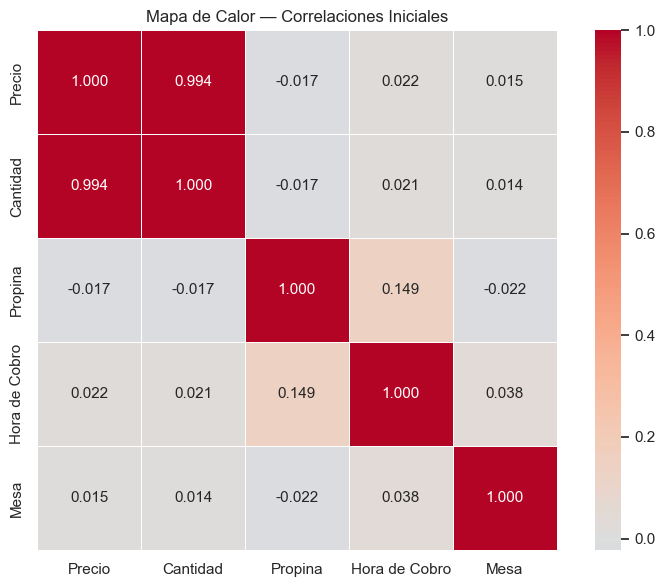


Correlaciones con Propina:
Propina          1.000000
Hora de Cobro    0.149328
Cantidad        -0.017242
Precio          -0.017261
Mesa            -0.022073


In [9]:
num_cols = ['Precio', 'Cantidad', 'Propina', 'Hora de Cobro', 'Mesa']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Mapa de Calor — Correlaciones Iniciales')
plt.tight_layout()
plt.savefig('heatmap_inicial.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nCorrelaciones con Propina:")
print(corr['Propina'].sort_values(ascending=False).to_string())


## 4. Preprocesamiento y Limpieza de Datos
Se identificaron los siguientes problemas a corregir:
| # | Problema | Estrategia | Justificación |
|---|----------|-----------|---------------|
| 1 | 1 fila duplicada | Eliminación | Introduce sesgo en el análisis |
| 2 | Typo en `Tipode`: "Recuerrente" | Corrección de texto | Error ortográfico evidente |
| 3 | `Hora de Cobro` en formato decimal | Conversión a horas reales | Mejor interpretabilidad |
| 4 | `Propina` como fracción | Conversión a pesos COP | Coherencia con `Precio` |
| 5 | Outliers en `Cantidad` (IQR) | Filtrado por IQR | Valores extremos distorsionan modelos |


In [10]:
df_clean = df.copy()

# ── Paso 1: Eliminar duplicados ──────────────────────────────────────────────
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"✅ Duplicados eliminados: {n_before - len(df_clean)}")

# ── Paso 2: Corregir typo en columna 'Tipode' ────────────────────────────────
df_clean['Tipode'] = df_clean['Tipode'].replace('Recuerrente', 'Recurrente')
print(f"✅ Typo corregido en 'Tipode': {df_clean['Tipode'].value_counts().to_dict()}")

# ── Paso 3: Convertir Hora de Cobro decimal → hora entera (0-23) ─────────────
df_clean['Hora de Cobro'] = (df_clean['Hora de Cobro'] * 24).round(0).astype(int).clip(0, 23)
print(f"✅ Hora de Cobro convertida. Rango: [{df_clean['Hora de Cobro'].min()}, {df_clean['Hora de Cobro'].max()}]")

# ── Paso 4: Convertir Propina de fracción a pesos COP ────────────────────────
df_clean['Propina'] = (df_clean['Propina'] * df_clean['Precio']).round(0).astype(int)
print(f"✅ Propina convertida a COP. Rango: [{df_clean['Propina'].min():,}, {df_clean['Propina'].max():,}]")

# ── Paso 5: Eliminar outliers en Cantidad usando IQR ─────────────────────────
Q1 = df_clean['Cantidad'].quantile(0.25)
Q3 = df_clean['Cantidad'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
n_before = len(df_clean)
df_clean = df_clean[(df_clean['Cantidad'] >= lower) & (df_clean['Cantidad'] <= upper)]
print(f"✅ Outliers de Cantidad eliminados: {n_before - len(df_clean):,} filas")

# ── Columna Hora_decimal y Hora_real (auxiliares — eliminar) ─────────────────
if 'Hora_decimal' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Hora_decimal', 'Hora_real'])

print(f"\n📊 Dataset limpio: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")


✅ Duplicados eliminados: 1
✅ Typo corregido en 'Tipode': {'Nuevo': 22438, 'Recurrente': 7693}
✅ Hora de Cobro convertida. Rango: [13, 23]
✅ Propina convertida a COP. Rango: [2, 258]
✅ Outliers de Cantidad eliminados: 1,182 filas

📊 Dataset limpio: 28,949 filas × 20 columnas


## 5. Perfilado Post-Limpieza y Comparación

In [11]:
print("=" * 50)
print("  COMPARACIÓN ANTES vs DESPUÉS")
print("=" * 50)
print(f"  Filas antes  : {df.shape[0]:,}")
print(f"  Filas después: {df_clean.shape[0]:,}  (−{df.shape[0]-df_clean.shape[0]:,})")
print(f"  Duplicados   : {df.duplicated().sum()} → 0")
print(f"  Typos Tipode : 'Recuerrente' → 'Recurrente'")
print(f"  Propina      : fracción → COP")
print(f"  Hora Cobro   : decimal  → entero (0-23)")
print("=" * 50)


  COMPARACIÓN ANTES vs DESPUÉS
  Filas antes  : 30,132
  Filas después: 28,949  (−1,183)
  Duplicados   : 1 → 0
  Typos Tipode : 'Recuerrente' → 'Recurrente'
  Propina      : fracción → COP
  Hora Cobro   : decimal  → entero (0-23)


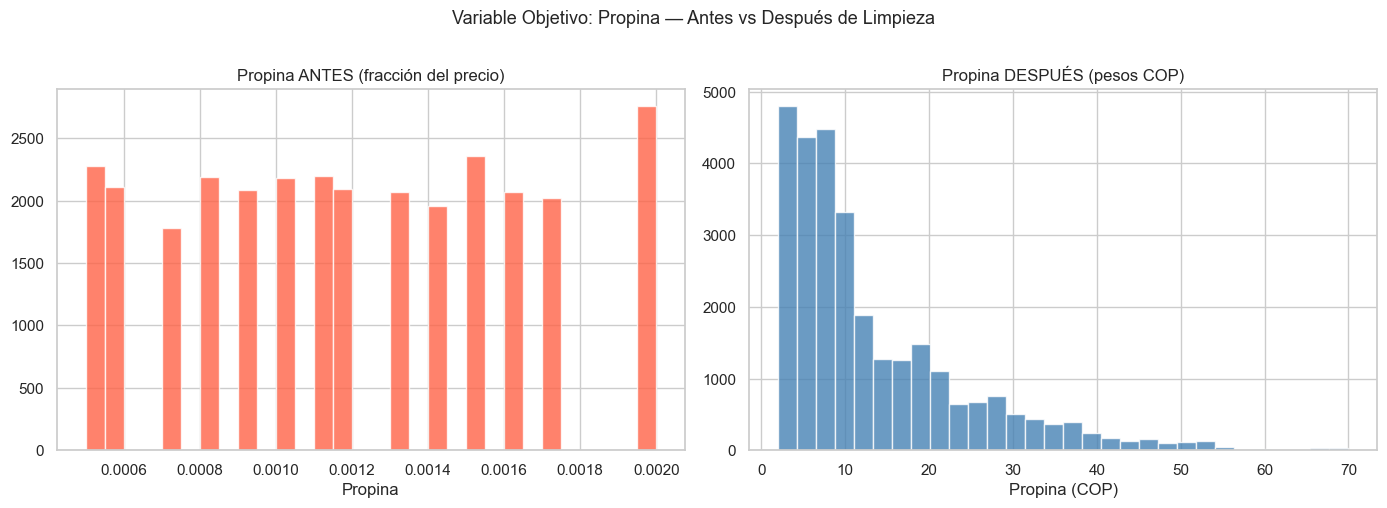

In [12]:
# Distribución Propina — Antes vs Después
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Propina'], bins=30, color='tomato', edgecolor='white', alpha=0.8)
axes[0].set_title('Propina ANTES (fracción del precio)')
axes[0].set_xlabel('Propina')

axes[1].hist(df_clean['Propina'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Propina DESPUÉS (pesos COP)')
axes[1].set_xlabel('Propina (COP)')

plt.suptitle('Variable Objetivo: Propina — Antes vs Después de Limpieza', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('propina_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()


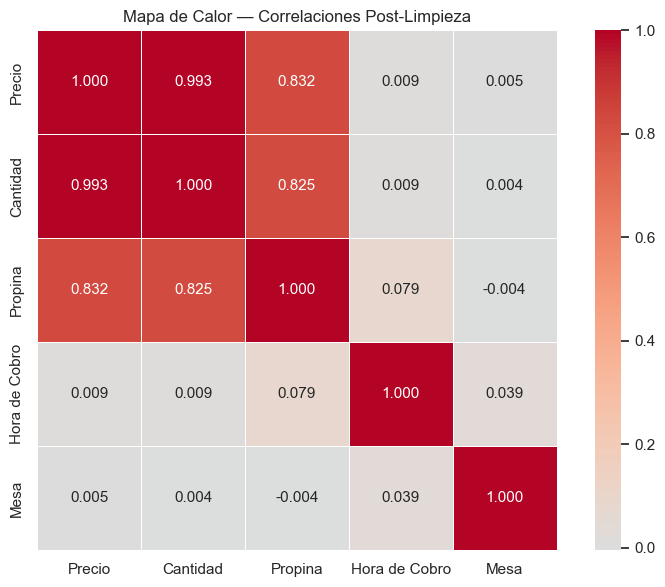


Correlaciones con Propina (post-limpieza):
Propina          1.000000
Precio           0.832115
Cantidad         0.825338
Hora de Cobro    0.079378
Mesa            -0.003958


In [13]:
# Heatmap post-limpieza
num_cols_clean = ['Precio', 'Cantidad', 'Propina', 'Hora de Cobro', 'Mesa']
corr_clean = df_clean[num_cols_clean].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_clean, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True)
plt.title('Mapa de Calor — Correlaciones Post-Limpieza')
plt.tight_layout()
plt.savefig('heatmap_limpio.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelaciones con Propina (post-limpieza):")
print(corr_clean['Propina'].sort_values(ascending=False).to_string())


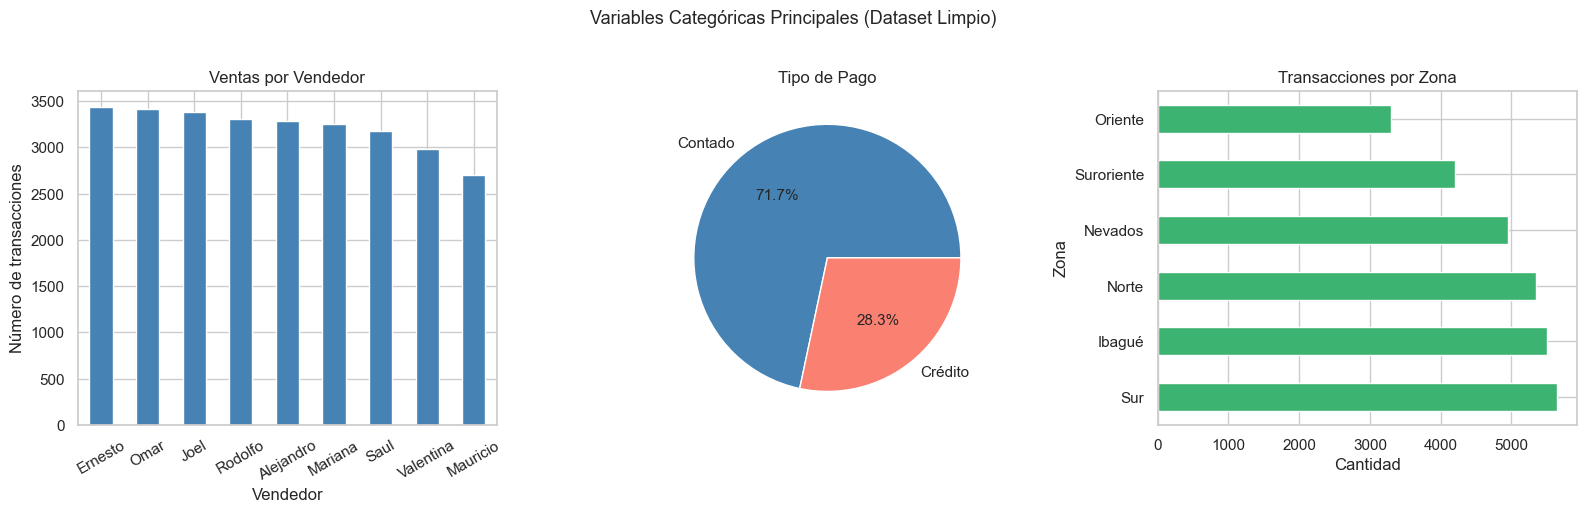

In [14]:
# Distribución de variables categóricas clave
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df_clean['Vendedor'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Ventas por Vendedor')
axes[0].set_ylabel('Número de transacciones')
axes[0].tick_params(axis='x', rotation=30)

df_clean['Tipo de pago'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                              colors=['steelblue', 'salmon'])
axes[1].set_title('Tipo de Pago')
axes[1].set_ylabel('')

df_clean['Zona'].value_counts().plot(kind='barh', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Transacciones por Zona')
axes[2].set_xlabel('Cantidad')

plt.suptitle('Variables Categóricas Principales (Dataset Limpio)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('categoricas_limpias.png', dpi=150, bbox_inches='tight')
plt.show()


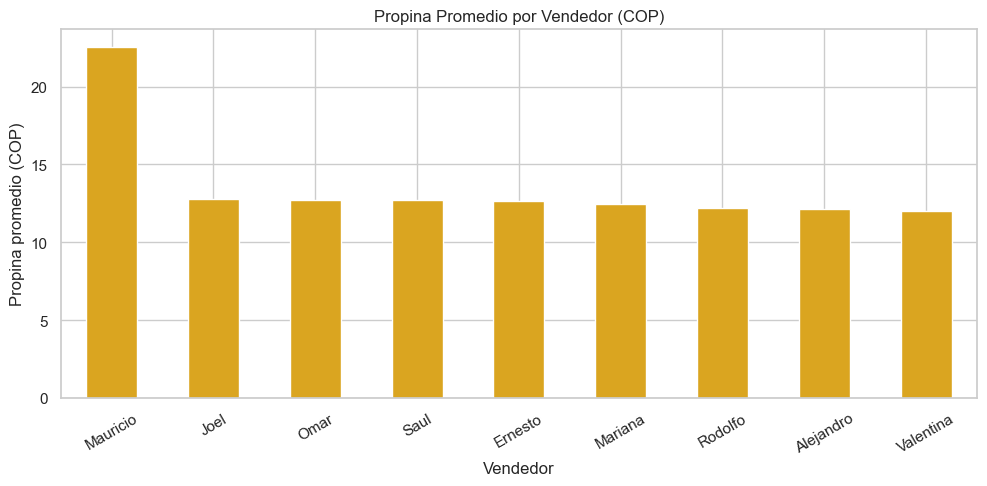

Vendedor
Mauricio     22.557778
Joel         12.780502
Omar         12.699678
Saul         12.696103
Ernesto      12.681012
Mariana      12.449939
Rodolfo      12.196126
Alejandro    12.123517
Valentina    12.014415


In [15]:
# Propina promedio por vendedor
propina_vendedor = df_clean.groupby('Vendedor')['Propina'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
propina_vendedor.plot(kind='bar', color='goldenrod', edgecolor='white')
plt.title('Propina Promedio por Vendedor (COP)')
plt.ylabel('Propina promedio (COP)')
plt.xlabel('Vendedor')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('propina_por_vendedor.png', dpi=150, bbox_inches='tight')
plt.show()
print(propina_vendedor.to_string())


## 6. Exportar Dataset Limpio

In [16]:
df_clean.to_csv("cafeteria_limpio.csv", index=False, encoding='utf-8-sig')
print(f"✅ Dataset exportado: 'cafeteria_limpio.csv'")
print(f"   Filas: {df_clean.shape[0]:,} | Columnas: {df_clean.shape[1]}")
print(f"\n--- RESUMEN FINAL ---")
df_clean.describe().round(2)


✅ Dataset exportado: 'cafeteria_limpio.csv'
   Filas: 28,949 | Columnas: 20

--- RESUMEN FINAL ---


,Fecha,Hora de Cobro,Mesa,Precio,Cantidad,Propina,Codigo Ciudad,Latitud,Longitud
count,28949,28949.00,28949.00,28949.00,28949.00,28949.00,28949.00,28949.00,28949.00
mean,2019-09-13 23:15:13.896853,18.69,9.14,11335.59,44.00,13.40,73405.01,4.32,-75.03
min,2018-02-01 00:00:00,13.00,1.00,3600.00,12.60,2.00,73001.00,3.20,-75.65
25%,2018-05-21 00:00:00,16.00,5.00,5000.00,18.50,6.00,73217.00,3.90,-75.12
50%,2018-09-14 00:00:00,19.00,9.00,8000.00,31.50,9.00,73408.00,4.20,-74.97
75%,2019-01-05 00:00:00,22.00,14.00,15600.00,63.00,18.00,73585.00,4.87,-74.89
max,2025-12-31 00:00:00,23.00,17.00,34800.00,132.84,70.00,73873.00,5.20,-74.53
std,NaN,3.20,4.89,7754.45,30.29,10.98,249.34,0.57,0.26
